# Optical Frequency Response Measurement
This notebook provides a step-by-step workflow for automating the measurement and analysis of optical frequency response in photonic experiments.
It leverages PyVISA to control laboratory instruments, load experiment configurations, acquire measurement data, and visualize results.

**Workflow Overview:**
1. Import required libraries and initialize instruments.
2. Load experiment configuration parameters.
3. Perform automated laser and sourcemeter sweeps.
4. Analyze and visualize measurement data.
5. Save results for further analysis.

---

In [1]:
import numpy as np
import pyvisa as visa
from instruments.santec_tsl570 import SantecTSL570
from instruments.agilent8163 import Agilent8163Multimeter
from instruments.keithley2400 import Keithley2400SourceMeter
from controllers.laser_sweep import *
from controllers.sourcemeter_sweep import measure_spectral_shift_vs_voltage
from utils.load_config import load_config
from utils.plotter import plot_spectral_shift_vs_voltage
from utils.data_saver import save_raw_measurements

/home/gcharala/.venvs/base/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## VISA Resource Discovery
This section lists all available VISA resources to ensure the required instruments are connected and recognized by the system before proceeding with measurements.

In [2]:
# from utils.visa_utils import list_gpib_resources
# list_gpib_resources()

In [3]:
# import pyvisa
# rm = pyvisa.ResourceManager('@py')
# inst = rm.open_resource('GPIB0::12::INSTR')
# inst.timeout = 1000
# print(inst.query('*IDN?'))

In [2]:
config = load_config('configs/experiment_config.yaml')
laser_cfg = config["SantecTSL570"]                          # Extract laser-specific configuration
power_cfg = config["Agilent8163Multimeter"]                 # Extract power meter-specific configuration
sourcemeter_cfg = config["Keithley2400"]           # Extract sourcemeter-specific configuration

combined_name = f"{config['DUT']['type']}_{config['DUT']['name']}"  # Combined name for saving data

In [5]:
rm = visa.ResourceManager()

# Generate the laser and sourcemeter objects using the configuration
laser_obj = SantecTSL570(
    address=laser_cfg['address'],
    resource_manager=rm
)

powermeter_obj = Agilent8163Multimeter(
    address=power_cfg['address'],
    resource_manager=rm
)

sourcemeter_obj = Keithley2400SourceMeter(
    address=sourcemeter_cfg['address'],
    resource_manager=rm
)

2026-05-04 17:20:13 | INFO | instruments.santec_tsl570 | Connected to SANTEC,TSL-570,22010084,0014.0011.0007 at GPIB0::1::INSTR
2026-05-04 17:20:13 | INFO | instruments.agilent8163 | Connected to HEWLETT-PACKARD,HP8163A,DE38700354,V5.01(54848) at GPIB0::12::INSTR
2026-05-04 17:20:13 | INFO | instruments.agilent8163 | Options: HP 81689A, 81634A
2026-05-04 17:20:13 | INFO | instruments.keithley2400 | Connected to KEITHLEY INSTRUMENTS INC.,MODEL 2401,4607731,B02 Jan 20 2021 10:19:49/B01  /W/N at GPIB0::25::INSTR
2026-05-04 17:20:13 | INFO | instruments.keithley2400 | Options: 0


## Laser Sweep Measurement and Analysis
This section performs the automated laser sweep, identifies the peak response, and visualizes the measurement results for analysis.

In [ ]:
# Set the power level
laser_obj.set_power(laser_cfg["power"])

measure_spectral_shift_vs_voltage_params = {
   "sourcemeter": sourcemeter_obj,
   "powermeter": powermeter_obj,
   "laser": laser_obj,
   "start_v": sourcemeter_cfg["start_voltage"],
   "stop_v": sourcemeter_cfg["stop_voltage"],
   "step_v": sourcemeter_cfg["step_voltage"],
   "start_wl": laser_cfg["start_wavelength"],
   "stop_wl": laser_cfg["stop_wavelength"],
   "step_wl": laser_cfg["step"],
   "measure_current_range": sourcemeter_cfg["measure_current_range"],
   "current_limit": sourcemeter_cfg["compliance_current"],
   "wire_mode": sourcemeter_cfg["wire_mode"],
   "sourcemeter_delay": sourcemeter_cfg["delay"],
   "powermeter_delay": power_cfg["delay"],
}

df_sweep = measure_spectral_shift_vs_voltage(**measure_spectral_shift_vs_voltage_params)
df_sweep.head()                                                   # peek
df_sweep[np.isclose(df_sweep["Voltage (V)"], 0.0)]                # one spectrum
df_sweep.pivot(index="Wavelength (nm)",                           # 2D grid
               columns="Voltage (V)",
               values="Power (dBm)")


# # Plot the laser sweep results
# plot_path = plot_measurements(headers=headers_laser_sweep, 
#            results= results_laser_sweep, 
#            figure_name=combined_name + "_Laser_Sweep", 
#            show=True,
#            )


2026-05-04 17:20:13 | INFO | instruments.santec_tsl570 | TSL-570 initialized. Command set: 0
2026-05-04 17:20:13 | INFO | instruments.agilent8163 | Laser module in slot 1 initialized.
2026-05-04 17:20:13 | INFO | instruments.keithley2400 | Source meter is initialized.
2026-05-04 17:20:13 | INFO | instruments.santec_tsl570 | Laser output turned ON.
V: 0.00→2.00, λ: 1310.000→1313.000 nm: 100%|██████████| 93/93 [00:38<00:00,  2.42pt/s]
2026-05-04 17:20:52 | INFO | instruments.santec_tsl570 | Laser output turned OFF.
2026-05-04 17:20:52 | INFO | instruments.keithley2400 | Source meter turned off.


## Plotting and Saving Results
This section visualizes the laser sweep data and saves the raw measurement results to a CSV file for documentation and further analysis.

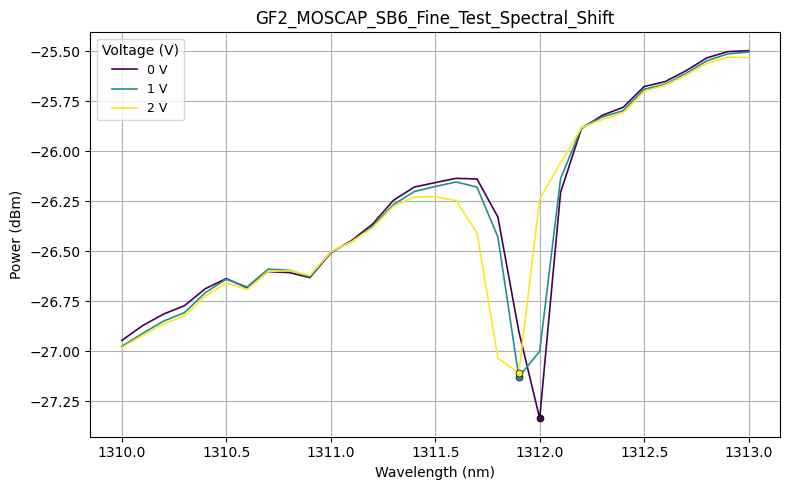

Plot saved as /home/gcharala/Documents/GitHub/pyvisa-lab-automation/plots/GF2_MOSCAP_SB6_Fine_Test_Spectral_Shift.png


In [ ]:
import pandas as pd
from utils.plotter import plot_spectral_shift_vs_voltage


df_sweep = pd.read_csv("sweep.csv")
plot_path = plot_spectral_shift_vs_voltage(
    df_sweep,
    figure_name=combined_name + "_Spectral_Shift",
    show=True,
)

df_sweep.to_csv("data/" + combined_name + "_Spectral_Shift.csv", index=False)



# # Save the laser sweep results to a CSV file
# data_path = save_raw_measurements(headers=headers_laser_sweep,
#                       data=results_laser_sweep,
#                       filename=combined_name + "_Laser_Sweep",
# )